In [1]:
import pandas as pd

terror_df = pd.read_excel(r"C:\Users\DELL\OneDrive\Desktop\Project sem 2\data\Terror.xlsx", sheet_name="count")
# or pd.read_csv("terrorism_data.csv")


In [2]:
country_map = {
    "Bosnia-Herzegovina": "Bosnia and Herzegovina",
    "Ivory Coast": "Côte d'Ivoire",
    "Swaziland": "Eswatini",
    "Macedonia": "North Macedonia",
    "Slovak Republic": "Slovakia",
    "East Timor": "Timor-Leste",

    # Congo
    "People's Republic of the Congo": "Congo",
    "Republic of the Congo": "Congo",
    "Zaire": "Congo",

    # Germany
    "East Germany (GDR)": "Germany",
    "West Germany (FRG)": "Germany",

    # Yemen
    "North Yemen": "Yemen",
    "South Yemen": "Yemen",

    # Historical states (drop)
    "Czechoslovakia": None,
    "Soviet Union": None,
    "Yugoslavia": None,

    # Palestine
    "West Bank and Gaza Strip": "Palestine"
}

"""terror_df["Country"] = terror_df["Country"].map(lambda x: country_map.get(x, x))

# Drop obsolete entities
terror_df = terror_df[terror_df["Country"].notna()]"""


'terror_df["Country"] = terror_df["Country"].map(lambda x: country_map.get(x, x))\n\n# Drop obsolete entities\nterror_df = terror_df[terror_df["Country"].notna()]'

In [3]:
import pandas as pd
# 2. Load master country list
# -------------------------------
file_path = r"C:\Users\DELL\OneDrive\Desktop\Project sem 2\data\Terror.xlsx"

countries_df = pd.read_excel(
    file_path,
    sheet_name="countries"
)

countries_df["COUNTRIES"] = countries_df["COUNTRIES"].str.strip()

# -------------------------------
# 3. Melt WIDE → LONG
# -------------------------------
terror_long = terror_df.melt(
    id_vars="Country",
    var_name="Year",
    value_name="Attacks"
)

terror_long["Year"] = terror_long["Year"].astype(int)
terror_long["Attacks"] = terror_long["Attacks"].fillna(0).astype(int)



In [4]:
# -------------------------------
# 4. Harmonize country names
# -------------------------------
terror_long["Country_mapped"] = terror_long["Country"].map(
    lambda x: country_map.get(x, x)
)

terror_long = terror_long[terror_long["Country_mapped"].notna()]

# -------------------------------
# 5. Aggregate AFTER mapping
# -------------------------------
terror_long = (
    terror_long
    .groupby(["Country_mapped", "Year"], as_index=False)
    .agg({"Attacks": "sum"})
    .rename(columns={"Country_mapped": "Country"})
)

# -------------------------------
# 6. Align with master country list
# -------------------------------

terror_long = terror_long.merge(
    countries_df,
    left_on="Country",
    right_on="COUNTRIES"
)


In [5]:
import os
# -------------------------------
# 7. Restrict to 1970–2020
# -------------------------------
terror_long = terror_long[
    (terror_long["Year"] >= 1970) &
    (terror_long["Year"] <= 2020)
]

# -------------------------------
# 8. Save to SEPARATE SHEET
# -------------------------------
if os.path.exists(file_path):
    with pd.ExcelWriter(
        file_path,
        mode="a",
        engine="openpyxl",
        if_sheet_exists="replace"
    ) as writer:
        terror_long.to_excel(
            writer,
            sheet_name="Terror_Long_1970_2020",
            index=False
        )
else:
    terror_long.to_excel(
        file_path,
        sheet_name="Terror_Long_1970_2020",
        index=False
    )


In [6]:
# -------------------------------
# 9. Sanity checks
# -------------------------------
print("Countries:", terror_long["Country"].nunique())
print("Years:", terror_long["Year"].min(), "-", terror_long["Year"].max())
print("Total attacks:", terror_long["Attacks"].sum())

Countries: 174
Years: 1970 - 2020
Total attacks: 207240


In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from functools import reduce
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import scipy.stats as stats
from scipy.stats import jarque_bera, shapiro

import statsmodels.api as sm


In [8]:
# Calculate % of NaN values in Attacks for each country
nan_percent = (
    terror_long
    .groupby("Country")["Attacks"]
    .apply(lambda x: x.isna().mean() * 100)  # % of missing values
)

# Sort descending to see countries with most missing values first
nan_percent = nan_percent.sort_values(ascending=False)

print(nan_percent)


Country
Afghanistan    0.0
Albania        0.0
Algeria        0.0
Andorra        0.0
Angola         0.0
              ... 
Venezuela      0.0
Vietnam        0.0
Yemen          0.0
Zambia         0.0
Zimbabwe       0.0
Name: Attacks, Length: 174, dtype: float64


In [14]:
# Keep only countries with at least one non-NaN 'Attacks' value
valid_countries = terror_long.groupby("Country")["Attacks"].apply(lambda x: x.notna().sum() > 0)

# Filter the dataset to include only these countries
terror_clean = terror_long[terror_long["Country"].isin(valid_countries[valid_countries].index)]

# Drop rows where 'Attacks' is NaN
terror_clean = terror_clean.dropna(subset=["Attacks"])

# Print the shape and first few rows for verification
print(f"After removing countries with all NaN values, data shape: {terror_clean.shape}")
print(terror_clean.head())


After removing countries with all NaN values, data shape: (8700, 4)
       Country  Year  Attacks    COUNTRIES
0  Afghanistan  1970        0  Afghanistan
1  Afghanistan  1971        0  Afghanistan
2  Afghanistan  1972        0  Afghanistan
3  Afghanistan  1973        1  Afghanistan
4  Afghanistan  1974        0  Afghanistan


In [15]:
# Check number of NaNs
print("NaNs:", terror_clean["Attacks"].isna().sum())

# Check number of infinite values
print("Infinite values:", np.isinf(terror_clean["Attacks"]).sum())

# Check number of negative infinite values
print("Negative Infinite values:", (terror_clean["Attacks"] == -np.inf).sum())

NaNs: 0
Infinite values: 0
Negative Infinite values: 0


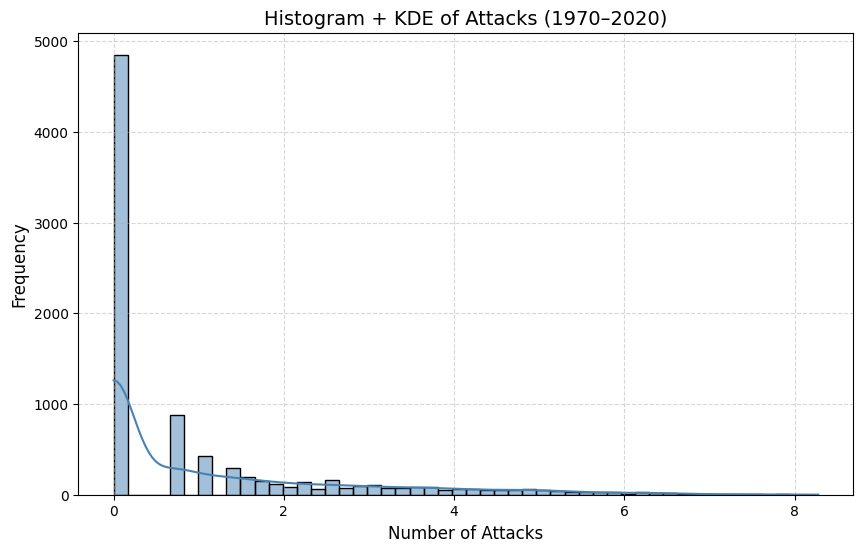

<Figure size 600x600 with 0 Axes>

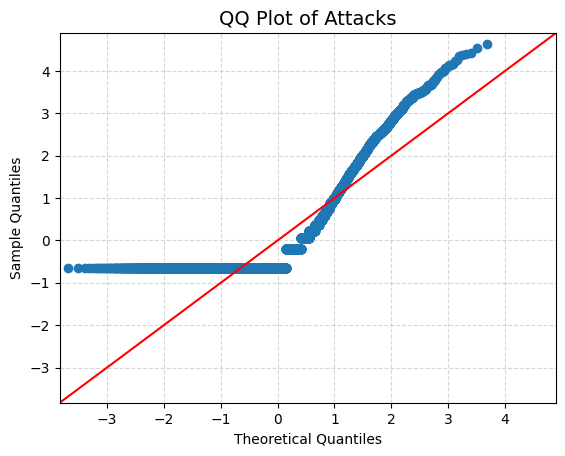

In [20]:
# Histogram + KDE
plt.figure(figsize=(10,6))
log_terror = np.log1p(terror_clean["Attacks"])
sns.histplot(log_terror, bins=50, kde=True, color='steelblue')
plt.title("Histogram + KDE of Attacks (1970–2020)", fontsize=14)
plt.xlabel("Number of Attacks", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# QQ Plot
plt.figure(figsize=(6,6))
sm.qqplot(log_terror, line='45', fit=True)
plt.title("QQ Plot of Attacks", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
# Ensure no NaNs in the column
attacks = terror_clean["Attacks"].dropna()

# Calculate skewness and excess kurtosis
skewness = stats.skew(attacks)
kurtosis = stats.kurtosis(attacks)  # excess kurtosis

print(f"Skewness: {skewness:.4f}")
print(f"Excess Kurtosis: {kurtosis:.4f}")

Skewness: 14.0311
Excess Kurtosis: 275.5511


In [21]:
from scipy.stats import shapiro, kstest, anderson, norm
import numpy as np

# Ensure no NaNs in the data
attacks = terror_clean["Attacks"].dropna()

# Kolmogorov-Smirnov Test (against normal distribution with sample mean & std)
mu, sigma = attacks.mean(), attacks.std()
stat, p = kstest(attacks, 'norm', args=(mu, sigma))
print("\nKolmogorov-Smirnov Test")
print(f"Statistic = {stat:.4f}, p-value = {p:.4f}")
if p < 0.05:
    print("  -> Reject null hypothesis: data is not normal")
else:
    print("  -> Fail to reject null hypothesis: data may be normal")

# Anderson-Darling Test
result = anderson(attacks, dist='norm')
print("\nAnderson-Darling Test")
print(f"Statistic = {result.statistic:.4f}")
for level, crit in zip(result.significance_level, result.critical_values):
    print(f"  {level}%: Critical Value = {crit:.4f} | {'Reject' if result.statistic > crit else 'Fail to Reject'}")



Kolmogorov-Smirnov Test
Statistic = 0.4279, p-value = 0.0000
  -> Reject null hypothesis: data is not normal

Anderson-Darling Test
Statistic = 2549.0099
  15.0%: Critical Value = 0.5760 | Reject
  10.0%: Critical Value = 0.6560 | Reject
  5.0%: Critical Value = 0.7870 | Reject
  2.5%: Critical Value = 0.9180 | Reject
  1.0%: Critical Value = 1.0910 | Reject


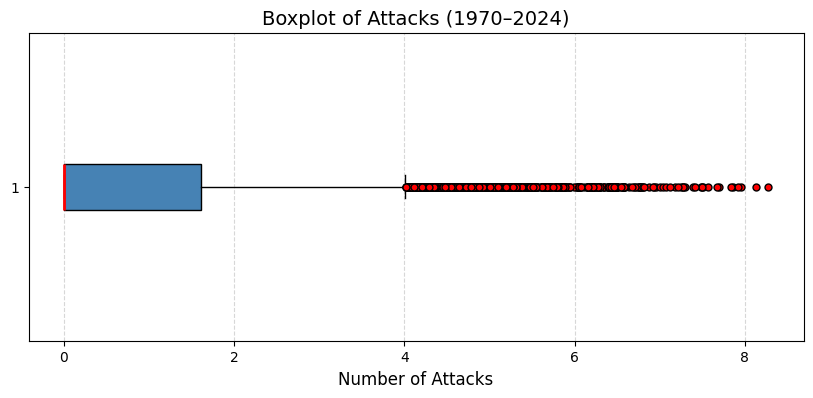

In [26]:
import matplotlib.pyplot as plt
log_terror = np.log1p(terror_long["Attacks"])
# Boxplot
plt.figure(figsize=(10, 4))
plt.boxplot(log_terror, vert=False, patch_artist=True, 
            boxprops=dict(facecolor='steelblue', color='black'),
            whiskerprops=dict(color='black'),
            capprops=dict(color='black'),
            medianprops=dict(color='red', linewidth=2),
            flierprops=dict(marker='o', markerfacecolor='red', markersize=5, linestyle='none'))
plt.title("Boxplot of Attacks (1970–2024)", fontsize=14)
plt.xlabel("Number of Attacks", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()


In [27]:
import numpy as np

# Compute IQR
Q1 = np.percentile(terror_clean["Attacks"], 25)
Q3 = np.percentile(terror_clean["Attacks"], 75)
IQR = Q3 - Q1

# Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
iqr_outliers = (terror_clean["Attacks"] < lower_bound) | (terror_clean["Attacks"] > upper_bound)

# Print results
print(f"IQR Outliers Count: {iqr_outliers.sum()}")
print(f"IQR Outliers Percentage: {iqr_outliers.mean() * 100:.2f}%")


IQR Outliers Count: 1482
IQR Outliers Percentage: 17.03%


In [28]:
import numpy as np

# Compute 1st and 99th percentiles
p1, p99 = np.percentile(terror_clean["Attacks"], [1, 99])

# Identify extreme values outside 1–99% range
extreme_quantiles = (terror_clean["Attacks"] < p1) | (terror_clean["Attacks"] > p99)

# Print results
print(f"1–99% Extreme Values Count: {extreme_quantiles.sum()}")
print(f"Percentage of Extreme Values: {extreme_quantiles.mean() * 100:.2f}%")
print(f"Lower 1% cutoff: {p1}")
print(f"Upper 99% cutoff: {p99}")


1–99% Extreme Values Count: 87
Percentage of Extreme Values: 1.00%
Lower 1% cutoff: 0.0
Upper 99% cutoff: 514.090000000002


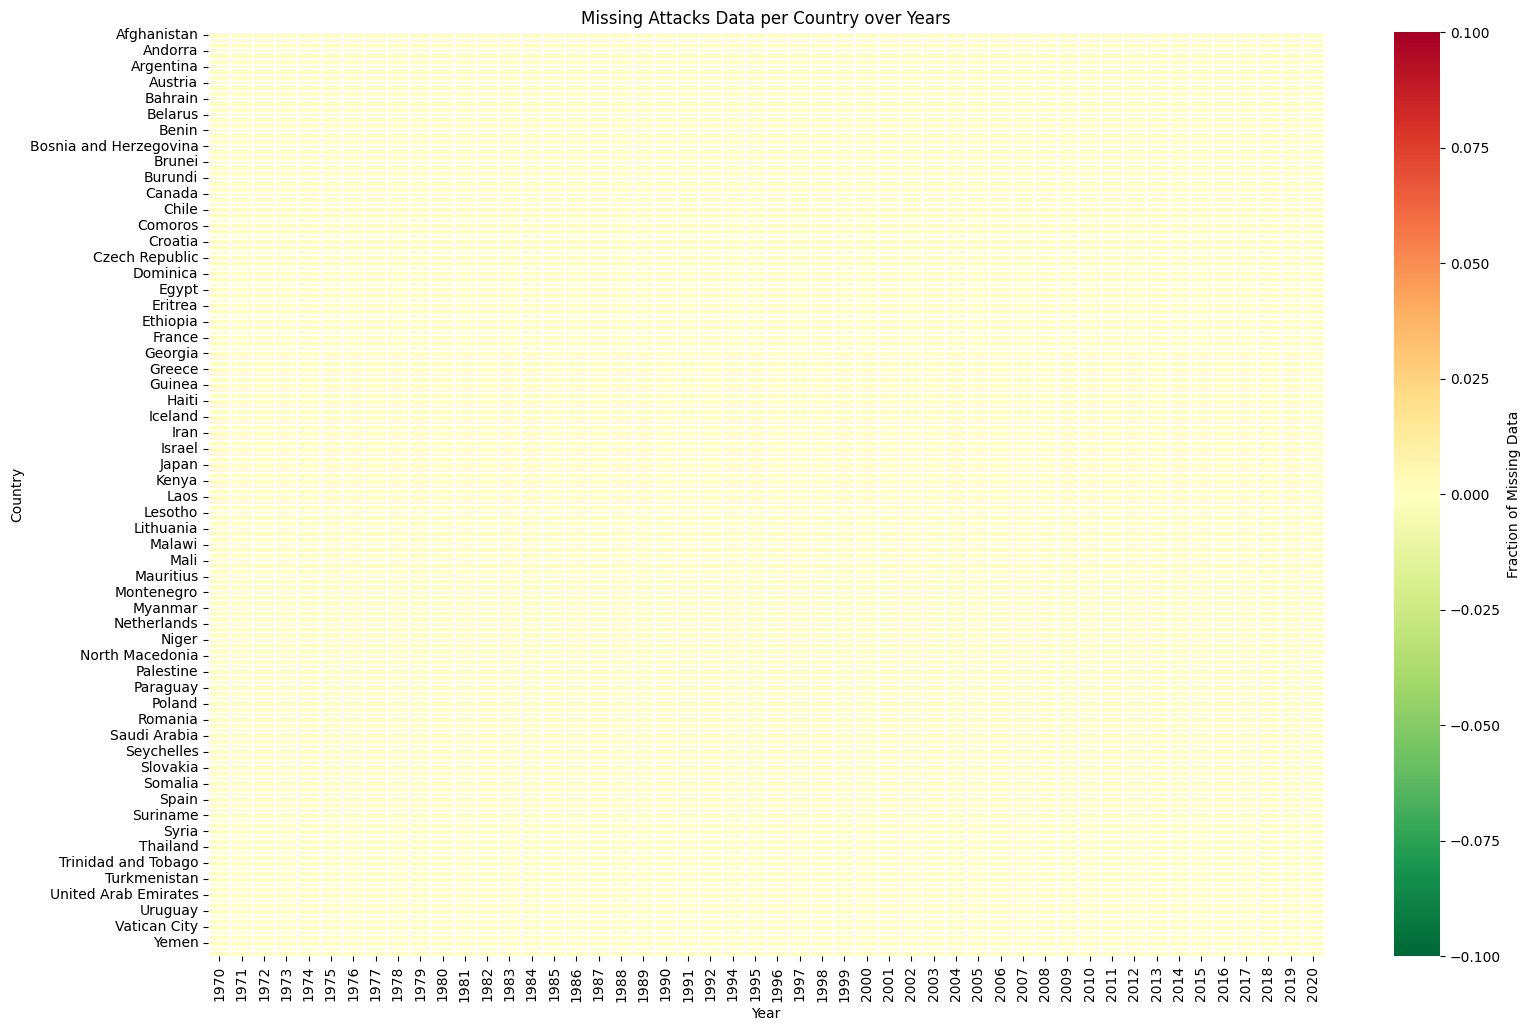

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Suppose your data is in terror_long with 'Country Name', 'Year', 'Attacks'

# Step 1: Calculate % missing attacks per country per year
missing_df = terror_long.pivot_table(
    index='Country',
    columns='Year',
    values='Attacks',
    aggfunc=lambda x: x.isna().mean()  # fraction of missing
)

# Step 2: Plot heatmap
plt.figure(figsize=(18, 12))
sns.heatmap(missing_df, cmap='RdYlGn_r', linewidths=0.3, cbar_kws={'label': 'Fraction of Missing Data'})
plt.title('Missing Attacks Data per Country over Years')
plt.ylabel('Country')
plt.xlabel('Year')
plt.show()
